### Import Libraries and Load Data

In [4]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve


# Style
%matplotlib inline
sns.set_style('whitegrid')

# Load the data
df = pd.read_csv('./WA_Fn-UseC_-Telco-Customer-Churn.csv')

### Initial Data Exploration

In [6]:
# First look at the data
print("Dataset Shape:",  df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("Data Info:")
df.info()

print("\nSummary Statistics")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget Variable Distibution:")
print(df['Churn'].value_counts())

Dataset Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Target Variable Distibution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


### Data Cleaning and Preprocessing\

In [10]:
# Create a copy of the original dataframe
df_clean = df.copy()

# 1. Handle missing values (if any were forund)
# The 'TotalCharges' column is object type but should be numeric. Let's convert it, forcing errors NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Check for new missing values in TotalCharges
print("Missing values after conversion:")
print(df_clean.isnull().sum)

# Drop the 11 rows with missing TotalCharges (a small fraction of the dataset)
df_clean = df_clean.dropna()

# 2. Handle unnecessary columns
# 'customerID' is a unique identifier and not useful for prediction.
df_clean = df_clean.drop('customerID', axis=1)

# 3. Encode categorical variables
# Seperate features and tearget
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# Label encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y) # 'No' -> 0, 'Yes' -> 1

# One-Hot Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True) # drop_first to avoid multicollinearity


print(f"Original features: {X.shape[1]}")
print(f"Features after encoding: {X_encoded.shape[1]}")

Missing values after conversion:
<bound method DataFrame.sum of       customerID  gender  SeniorCitizen  ...  MonthlyCharges  TotalCharges  Churn
0          False   False          False  ...           False         False  False
1          False   False          False  ...           False         False  False
2          False   False          False  ...           False         False  False
3          False   False          False  ...           False         False  False
4          False   False          False  ...           False         False  False
...          ...     ...            ...  ...             ...           ...    ...
7038       False   False          False  ...           False         False  False
7039       False   False          False  ...           False         False  False
7040       False   False          False  ...           False         False  False
7041       False   False          False  ...           False         False  False
7042       False   False          

### 4. Exploratory Data Analysis (EDA)

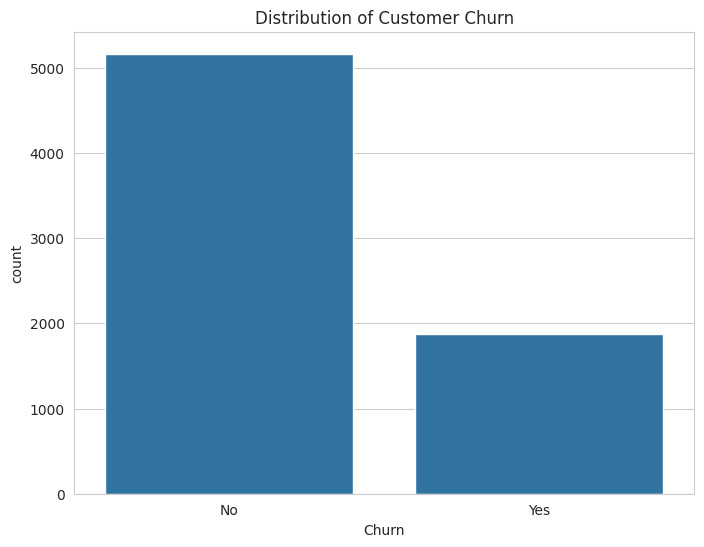

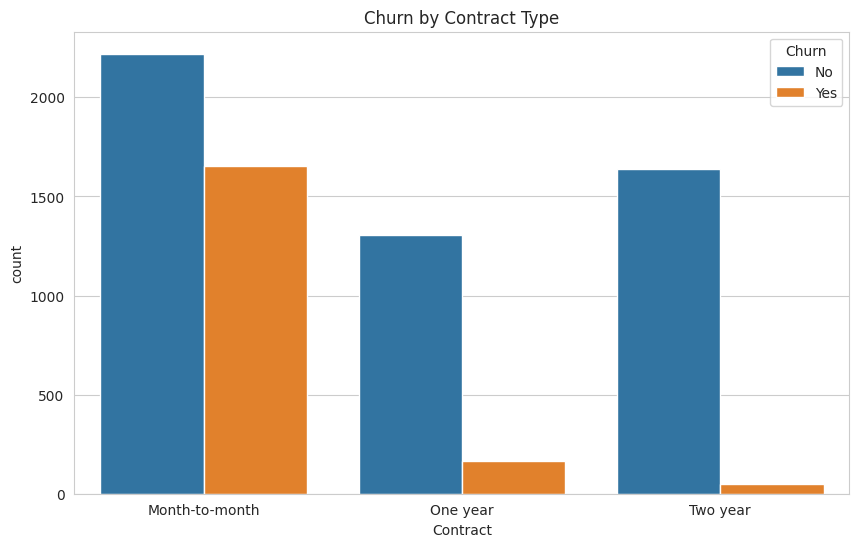

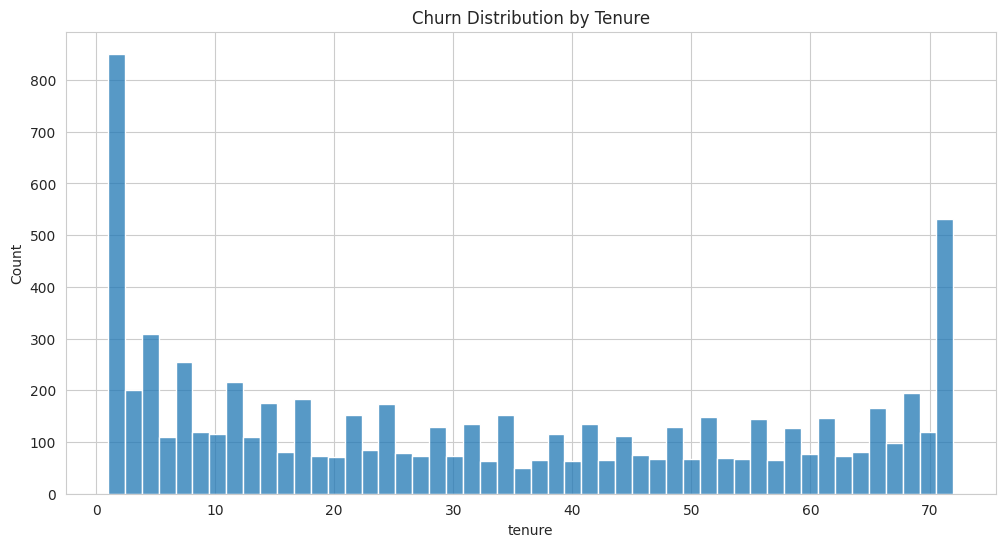

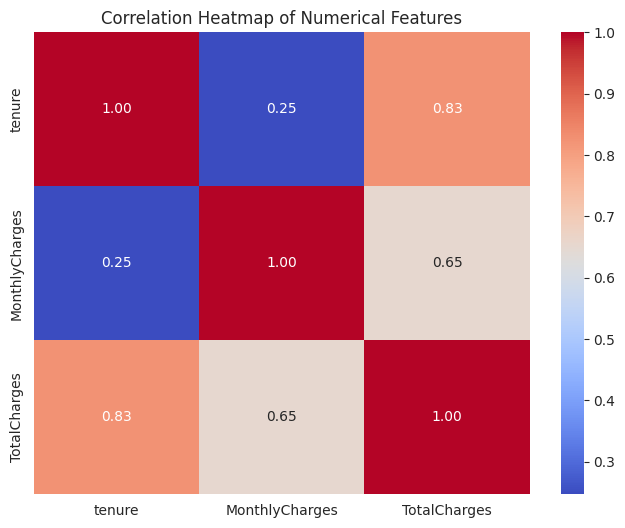

In [12]:
# 1. Churn Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=df_clean)
plt.title('Distribution of Customer Churn')
plt.show()

# 2. Churn by Contract Type
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df_clean)
plt.title('Churn by Contract Type')
plt.show()

# 3. Churn by Tenure
plt.figure(figsize=(12, 6))
sns.histplot(data=df_clean, x='tenure', multiple="stack", bins=50)
plt.title('Churn Distribution by Tenure')
plt.show()

# 4. Correlation Heatmap (for numerical features)
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### 5. Feature Engineering & Train-Test Split

In [13]:
# We've already done the main encoding. Now let's split the data.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale the features for models that are sensitive to feature scales (like SVM and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (5625, 30)
Test set size: (1407, 30)


### 6. Model Building & Evaluation

In [14]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42, probability=True) # probability=True for ROC curve
}

# Dictionary to store results
results = {}

# Train, predict, and evaluate each model
for name, model in models.items():
    # Choose scaled or unscaled data
    if name in ['Logistic Regression', 'Support Vector Machine']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    # Train the model
    model.fit(X_tr, y_train)

    # Make predictions
    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1] # Probabilities for the positive class

    # Calculate metrics
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    # Store results
    results[name] = {
        'model': model,
        'f1_score': f1,
        'auc_score': auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    # Print results
    print(f"\n{name} Results:")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression Results:
F1-Score: 0.6091
AUC-ROC: 0.8357
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Random Forest Results:
F1-Score: 0.5673
AUC-ROC: 0.8165
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Support Vector Machine Results:
F1-Score: 0.5509
AUC-ROC: 0.7909
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       3

### 7. Model Comparison & Selection

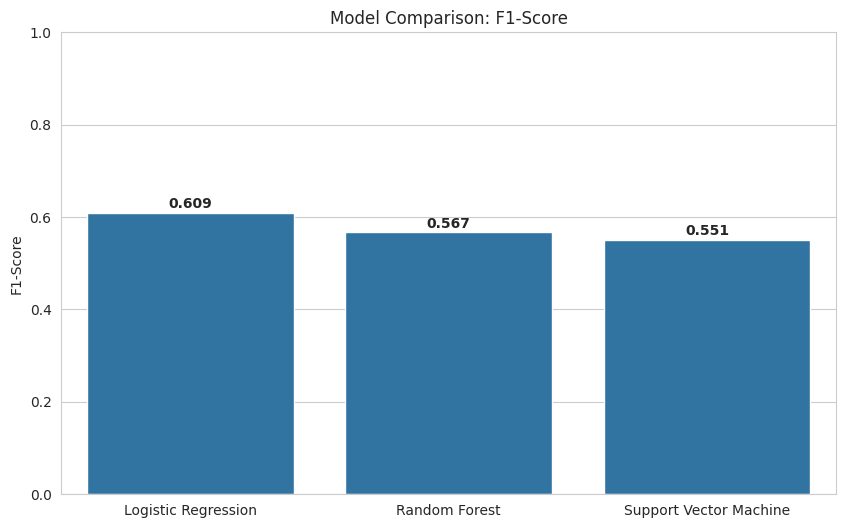

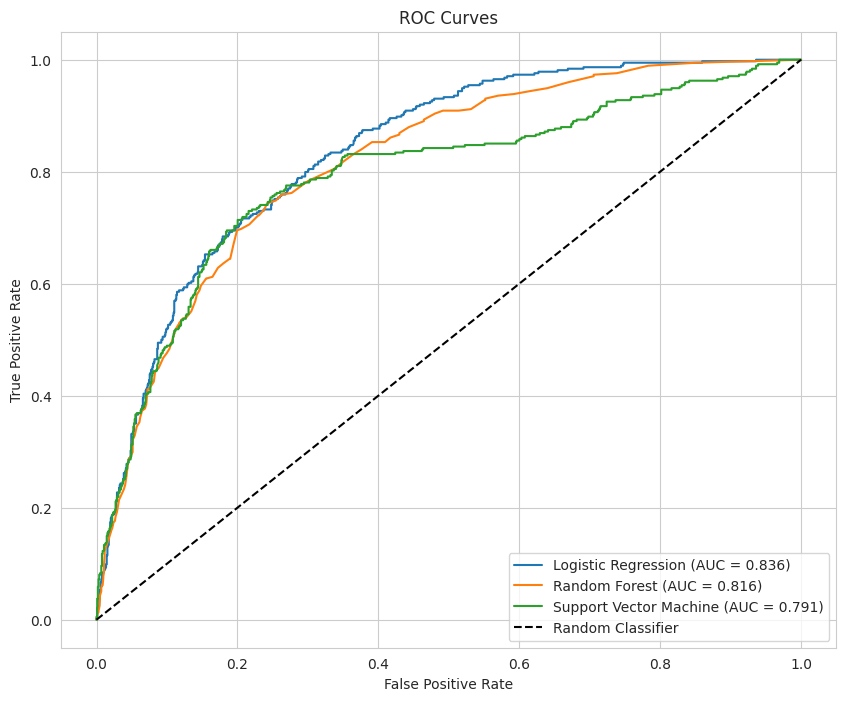

In [15]:
# Compare F1-Scores
model_names = list(results.keys())
f1_scores = [results[name]['f1_score'] for name in model_names]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=f1_scores)
plt.title('Model Comparison: F1-Score')
plt.ylim(0, 1)
plt.ylabel('F1-Score')
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

# Plot ROC Curves
plt.figure(figsize=(10, 8))
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['probabilities'])
    auc = results[name]['auc_score']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()